# $(SA)^3$

$loss = mse(\hat{\theta'},\hat{\theta}) + mse(\hat{s''},s'') + mse(\hat{s'''},y)$ 


## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *

import gymnasium as gym
import rlenvs

In [2]:
n_episodes = 100

# env = gym.make("custom/DiscreteCartPole-v1")
env = gym.make("custom/CartPole-v1")

data = [generate_episode(env=env, seed=i) for i in range(n_episodes)]
# for i in data:
#     print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [3]:
def build_data2(data, dimensions=None):
    dimensions = dimensions if dimensions is not None else {
        's': 2, 'a':1, 'r': 1, 'p':2
    }
    iS = dimensions['s']
    iA = iS+dimensions['a']
    iR = iA+dimensions['r']
    iP = iR+dimensions['p']
    iS_ = iP+dimensions['s']

    s,a,r,p,s_ = data[:-2,:iS], data[:-2,iS:iA], data[:-2,iA:iR], data[:-2,iR:iP], data[:-2,iP:iS_] 
    s_,a_,r_,p_,s__ =  data[1:-1,:iS], data[1:-1,iS:iA], data[1:-1,iA:iR], data[1:-1,iR:iP], data[1:-1,iP:iS_] 
    s__,a__,r__,p__,s___ =  data[2:,:iS], data[2:,iS:iA], data[2:,iA:iR], data[2:,iR:iP], data[2:,iP:iS_] 

    input_all = np.concat([s, a, s_, a_, s__, a__, s___, r__, p, p_], axis=1)

    return input_all

def train_data2(data, random=True, dimensions=None):
    dimensions = dimensions if dimensions is not None else {
        's': 2, 'a':1, 'r': 1, 'p':2
    }

    if random:
        n = data.shape[0]
        index = np.random.choice(n, n, replace=False)  
    else:
        index = np.arange(n)

    dataset = data[index]

    input_index = dimensions['s']*3 + dimensions['a']*3
    input_all = dataset[:,:input_index]
    output_all = dataset[:, input_index:]

    X = torch.tensor(input_all, dtype=torch.float32)
    y = torch.tensor(output_all, dtype=torch.float32)
    return X,y


In [ ]:
class TransitionEstimatorBaseS3(nn.Module):
    def __init__(self, s,a, hidden_size, output):
        super(TransitionEstimatorBaseS3, self).__init__()
        self.input_set = sum([s,a,s,a,s,a])

        self.l1 = nn.Linear(self.input_set, hidden_size)
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l3 = nn.Linear(hidden_size, output)
        self.relu = nn.ReLU()
        self.than = nn.Tanh()

    def forward(self, x, mode='all'):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        out = self.than(out)
        out = self.l3(out)
        return out
    
class TransitionEstimatorS3(nn.Module):
    def __init__(self, s,a,p, hidden_size, output):
        super(TransitionEstimatorS3, self).__init__()
        self._s = s
        self._a = a
        self._p = p

        self.input_param = sum([s,a,s])
        self.input_param_ = sum([s,a,s])
        self.input_state = sum([s,a,p])
        self.input_state_ = sum([s,a,p])
        
        self.par1 = nn.Linear(self.input_param, hidden_size)
        self.par2 = nn.Linear(hidden_size, p)
        self.s1 = nn.Linear(self.input_state, hidden_size)
        self.s2 = nn.Linear(hidden_size, output)
        self.relu = nn.ReLU()
        self.than = nn.Tanh()


    def forward_param(self, x):
        """
            x: Input data of format (s, a, s') for estimating only the parameters (p)
        """
        out = self.par1(x)
        out = self.relu(out)
        out = self.par2(out)

        return out
    
    def forward_state(self, x):
        """
            x: Input data of format (s', a', p) for estimating only the state (s'')
        """
        out = self.s1(x)
        out = self.than(out)
        out = self.s2(out)

        return out

    def forward(self, x, mode='all'):
        """
            x: Input data (s,a,s_,a_,s__,a__)
        """
        assert x.shape[1] == (self._s*3 + self._a*3), f"Invalid input format ({x.shape[1]}) expected ({(self._s*3 + self._a*3)})"
        # if mode in ('all', 'param'):
        #     out = self.forward_param(x[:,:self.input_param])
        # if mode == 'all':
        #     input_state = self.input_param - self._s
        #     x = torch.concat([x[:,input_state:], out], axis=1)
        # if mode in ('all', 'state'):
        #     out = self.forward_state(x)

        pInput = x[:, :self._s + self._a + self._s]
        p = self.forward_param(pInput)
        
        s__Input = torch.concat([x[:, self._s+self._a : self._s+self._a+self._s+self._a], p], axis=1)
        s__ = self.forward_state(s__Input)

        p_Input = x[:, self._s+self._a : self._s+self._a+self._s+self._a+self._s]
        p_ = self.forward_param(p_Input)
        
        s___Input = torch.concat([x[:, self._s+self._a+self._s+self._a :], p_], axis=1)
        s___ = self.forward_state(s___Input)

        self.p = p
        self.s__ = s__
        self.s__Target = x[:, self._s+self._a+self._s+self._a : self._s+self._a+self._s+self._a+self._s]
        self.p_ = p_
        self.s___ = s___
        out = s___

        return out

class Normalizer2(Normalizer):
    def replace_infinity(self, value, replace):
        return value
    def normilize(self, value, params):
        return value
    def denormilize(self, value, params):
        return value

class MyLoss(nn.MSELoss):
    def forward(self, output, target):
        p = self._Model__estimator.p
        p_ = self._Model__estimator.p_
        s__ = self._Model__estimator.s__
        s__Target = self._Model__estimator.s__Target

        mse_s___ = super().forward(output, target)
        mse_s__ = super().forward(s__, s__Target)

        p_dist = super().forward(p, p_)
        # p_dist = torch.pow(p-p_, 2)/p.shape[0]

        loss = torch.mean((mse_s___ + mse_s__) + p_dist**2)
        return loss


In [5]:
n_agents = 10

pmbrl = [Model(
        normalizer_clss=Normalizer2,
        estimators_clss=[TransitionEstimatorS3, RewardEstimatorBase], 
        criterion_clss=[MyLoss, nn.BCELoss], 
        learning_rate=[0.0001,0.001]
    ) for _ in range(n_agents)]
mbrl = [ModelBase(
        normalizer_clss=Normalizer2, 
        estimators_clss=[TransitionEstimatorBaseS3, RewardEstimatorBase], 
        learning_rate=[0.0001,0.001]
    ) for _ in range(n_agents)]

In [6]:
training = { # Traning:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 1000, # Number of epochs on training
}

def run(data, models, val=200, verbose=False):
    results = []
    dataset = np.concat(data, axis=0)
    X, y = train_data2(build_data2(dataset))
    
    for j, agent in enumerate(models):
        if verbose:
            print(f'Agent {j}...')
        agent.train(X[:-val], y[:-val, :-4], **training)
        s,r = agent.sample(X[-val:], mode=training['mode'])
        # p,_ = agent.sample(X[-val:, :-1], mode='param')
        results.append(torch.concat([
                torch.tensor([j]*val).unsqueeze(1),
                (torch.mean((s - y[-val:,:2])**2, axis=0)**.5).repeat(val, 1),
                (torch.mean((r - y[-val:,2])**2, axis=0)**.5).unsqueeze(1)
            ], axis=1))
    
    d = np.array(results).reshape(len(results)*val, results[0].shape[1])
    return pd.DataFrame(d, columns=['agent', 's_0', 's_1', 'r']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [7]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

# pmbrl_plot = pmbrl_results.groupby(by='epi').mean()[['s_0','s_1','r', 'p_0', 'p_1']]
pmbrl_plot = pmbrl_results.groupby(by='agent').mean()[['s_0','s_1','r']]

Training pmbrl...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
pmbrl done!


In [8]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

# mbrl_plot = mbrl_results.groupby(by='epi').mean()[['s_0','s_1','r', 'p_0', 'p_1']]
mbrl_plot = mbrl_results.groupby(by='agent').mean()[['s_0','s_1','r']]

Training mbrl...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
mbrl done!


In [9]:
def add_plot(name, data, axis, reffs, colors=('g', 'b', 'r')):
    # reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(data['s_0'], color = colors[0])
    axis[0].plot(reffs[0], linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5)/10)

    axis[1].plot(data['s_1'], color = colors[1])
    axis[1].plot(reffs[1], linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5)/10)

    axis[2].plot(data['r'], color = colors[2])
    axis[2].plot(reffs[2], linestyle = 'dotted', color = 'r')
    axis[2].set_yticks(np.arange(5)/10)


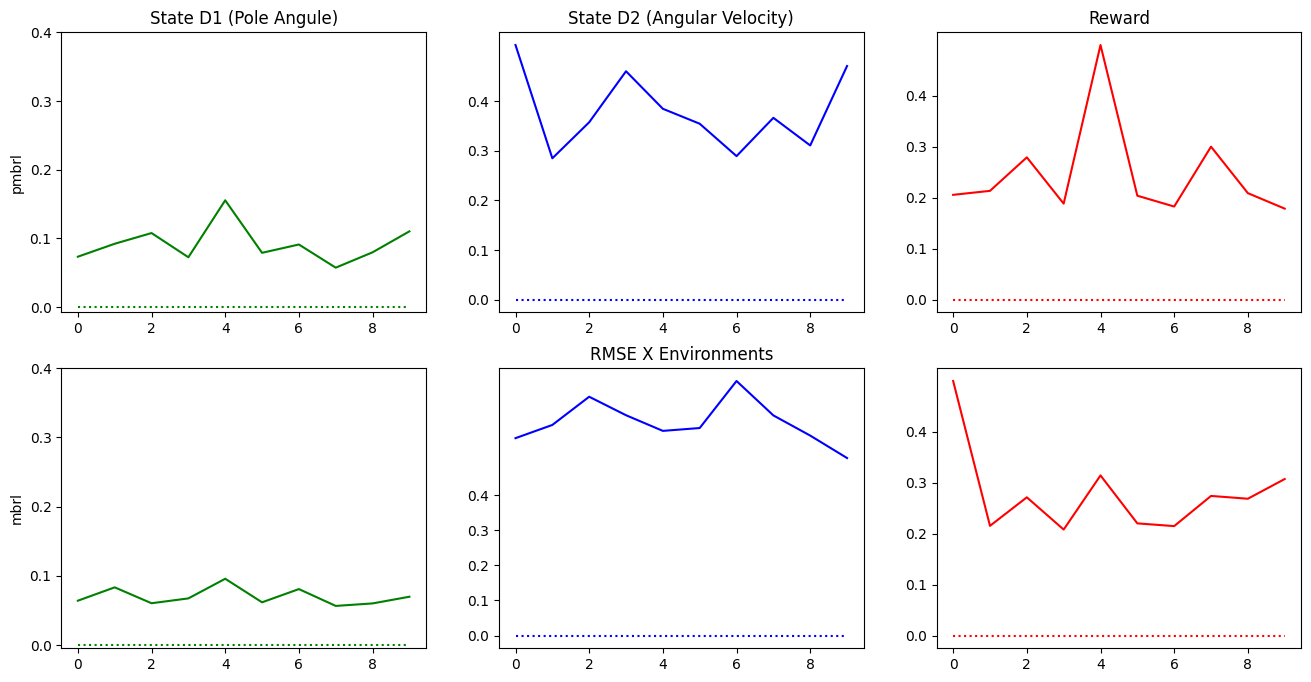

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X Environments')

reff = np.zeros(pmbrl_plot.shape[0])

add_plot(f'pmbrl', pmbrl_plot, axs[0], (reff,reff,reff))
add_plot(f'mbrl', mbrl_plot, axs[1], (reff,reff,reff))

plt.show()

# Teste

In [18]:
# for epi in data:
#     print(epi[0])

In [19]:
# for epi in data:
#     print(epi[1])

In [13]:
n_episodes = 10

env = gym.make("custom/CartPole-v1")
data = [generate_episode(env=env) for _ in range(n_episodes)]

for i in data:
    print(i.shape)

(10, 8)
(14, 8)
(17, 8)
(9, 8)
(16, 8)
(30, 8)
(5, 8)
(8, 8)
(7, 8)
(39, 8)


/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [14]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        # X, y = build_train_data(epi)
        X, y = train_data2(build_data2(epi))
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, (feature, target) in enumerate(zip(X,y)):
                s,r = agent.sample(torch.unsqueeze(feature, axis=0), mode=training['mode'])
                # p,_ = agent.sample(torch.unsqueeze(feature, axis=0)[:, :-1], mode='param')
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        torch.mean((s - target[:2])**2, axis=0)**.5,
                        torch.mean((r - target[2])**2, axis=0)**.5,
                        # p[0],
                        # y[-1, 3:]
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r']) 


In [15]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by=['epi','step']).mean()[['s_0','s_1','r']].reset_index()

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 4...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 5...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 6...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 7...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9..

In [16]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by=['epi','step']).mean()[['s_0','s_1','r']].reset_index()

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 4...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 5...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 6...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Episode 7...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...

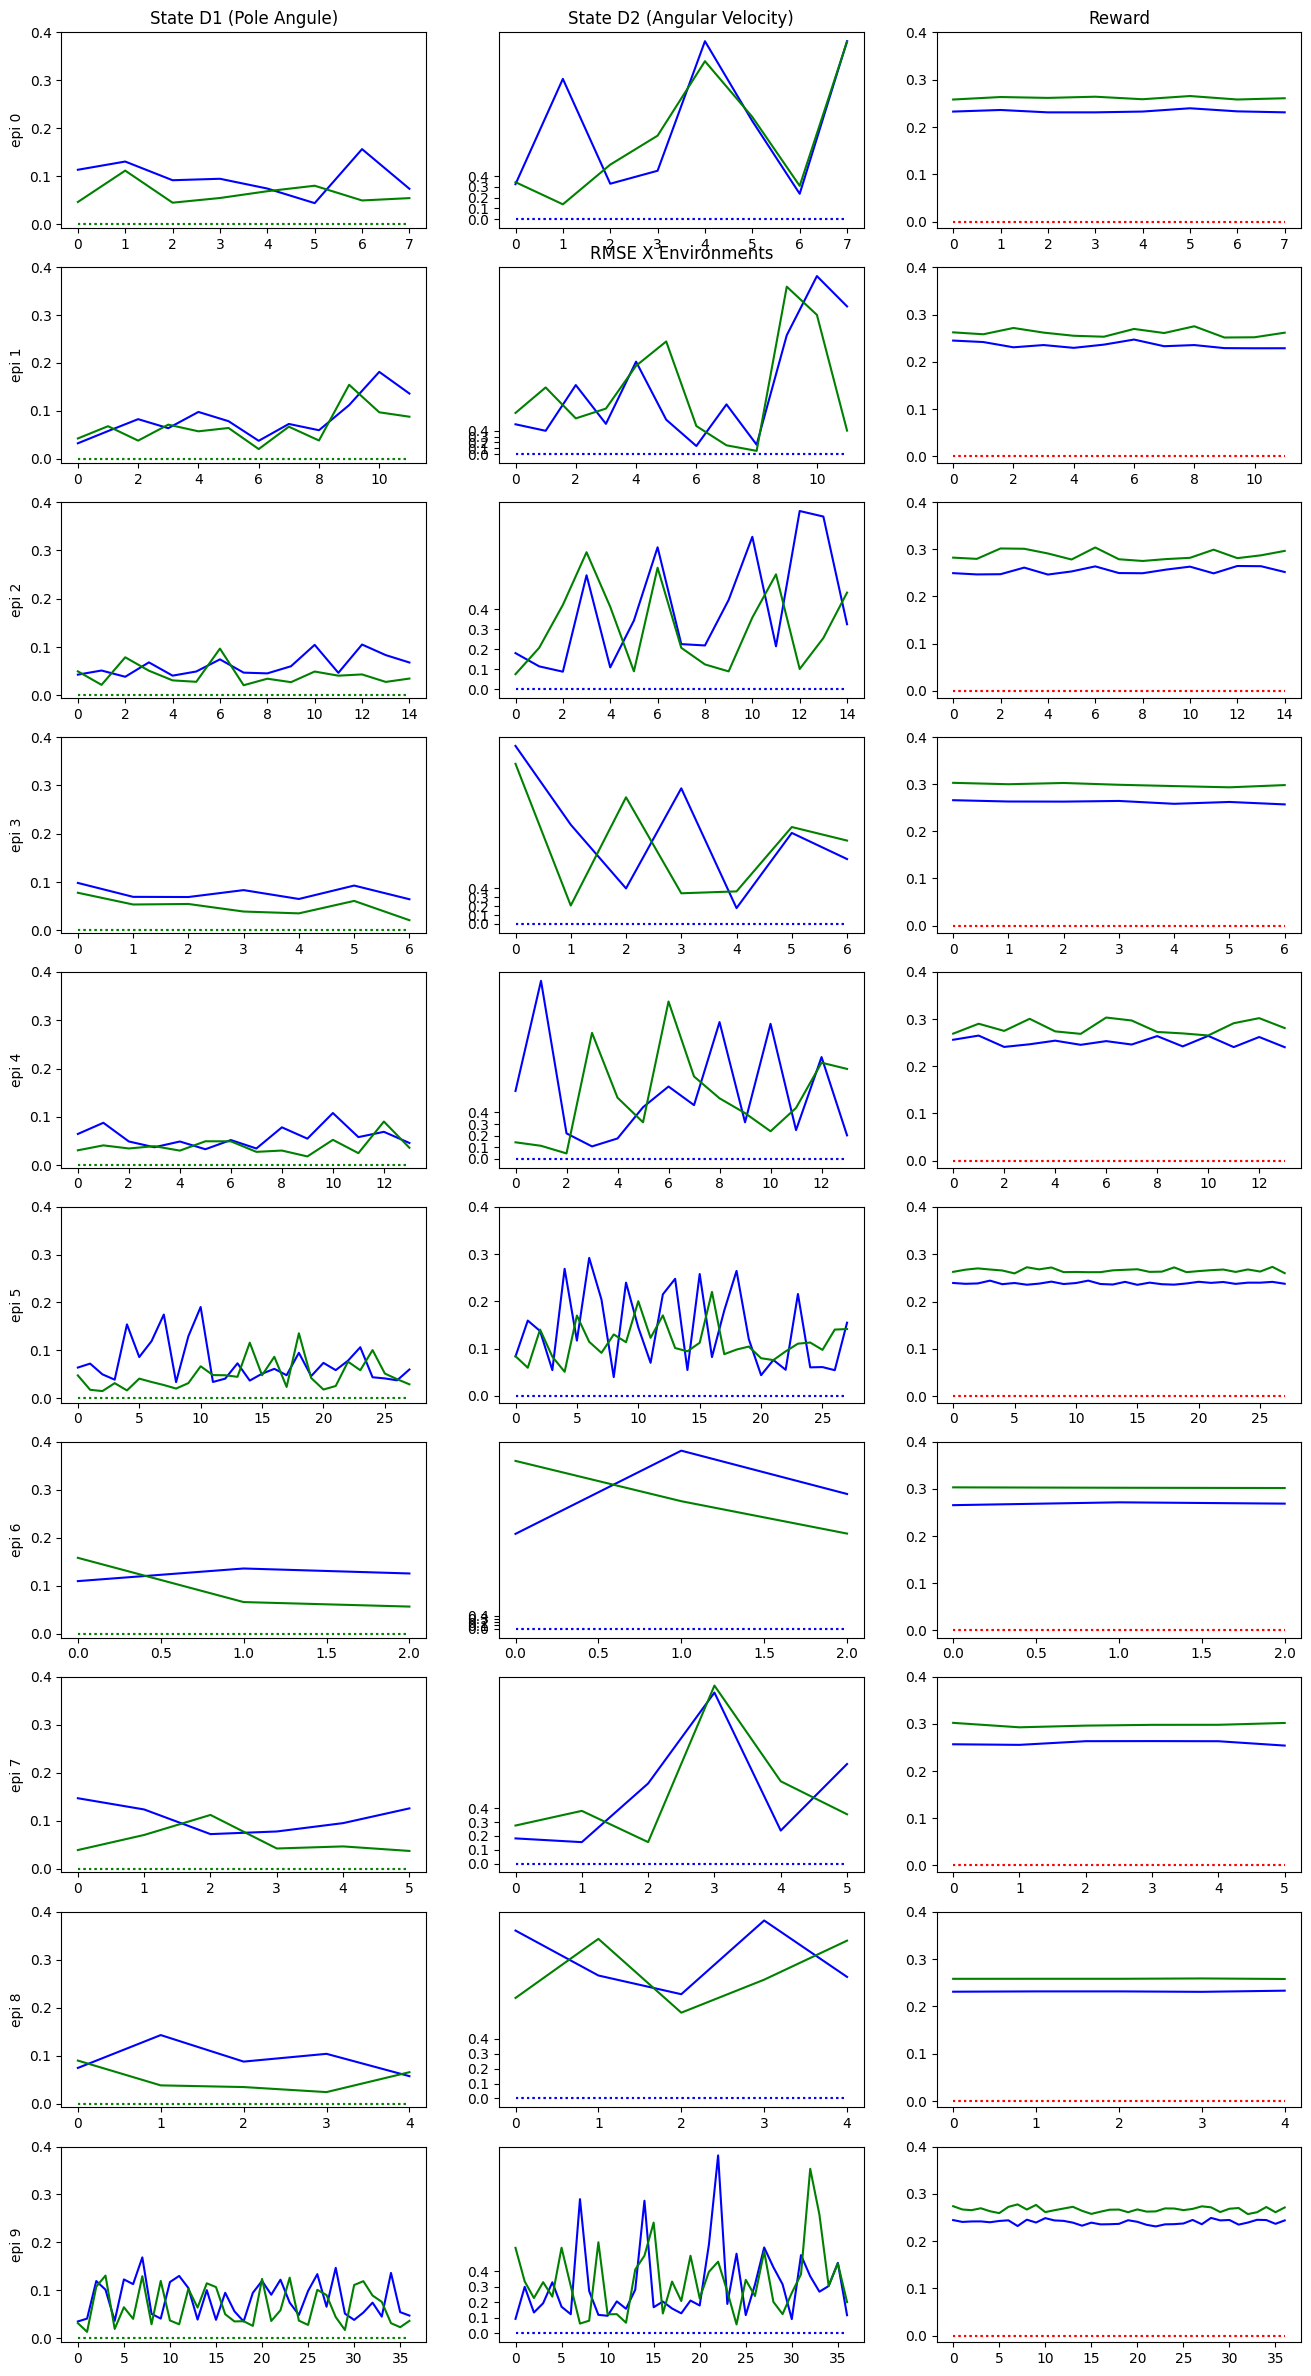

In [17]:
n = pmbrl_results.epi.drop_duplicates().size

fig, axs = plt.subplots(n, 3, figsize=(16, n*3))

# axs[0][0].set_title('Param D1 (masspole)')
# axs[0][1].set_title('Param D2 (length)')

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X Environments')


for i in range(n):
    df = pmbrl_plot[pmbrl_plot.epi==i].reset_index()
    reff = np.zeros(df.shape[0])
    add_plot(
        f'epi {i}', 
        df, 
        axs[i],
        (reff, reff, reff),
        ('b', 'b', 'b')
    )
    
    df = mbrl_plot[mbrl_plot.epi==i].reset_index()
    reff = np.zeros(df.shape[0])
    add_plot(
        f'epi {i}', 
        df, 
        axs[i],
        (reff, reff, reff),
        ('g', 'g', 'g')
    )

plt.show()